# Notebook 01 — Discovery
## Projet Machine Learning : Healthy Illusion
**Détection des produits alimentaires à illusion saine**

---

Ce notebook réalise l'exploration initiale du dataset collecté.

**Objectifs :**
1. Charger le dataset
2. Vérifier les dimensions et les types de variables
3. Calculer les statistiques de base
4. Vérifier le déséquilibre de la variable cible `bad_nutrition`
5. Confirmer que le dataset est exploitable pour la Phase 2

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style des graphiques
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Imports OK')

Imports OK


## 1. Chargement du dataset

In [2]:
# Chemin du dataset — ajuste si nécessaire
DATASET_PATH = 'data/dataset.csv'

# Assurer l'existence du dossier de sortie
import os
os.makedirs('data', exist_ok=True)

df = pd.read_csv(DATASET_PATH, low_memory=False) if os.path.exists(DATASET_PATH) else pd.DataFrame()

print(f' Dataset chargé avec succès')
print(f'   Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

 Dataset chargé avec succès
   Dimensions : 15,114 lignes × 18 colonnes


## 2. df.info() — Types et valeurs manquantes

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15114 entries, 0 to 15113
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                15114 non-null  object 
 1   product_name        14840 non-null  str    
 2   brands              14710 non-null  str    
 3   main_category       15114 non-null  str    
 4   country             15114 non-null  str    
 5   sugars_100g         15114 non-null  float64
 6   fat_100g            15114 non-null  float64
 7   saturated_fat_100g  15114 non-null  float64
 8   salt_100g           15114 non-null  float64
 9   fiber_100g          15114 non-null  float64
 10  proteins_100g       15114 non-null  float64
 11  energy_kcal_100g    15114 non-null  float64
 12  additives_count     15114 non-null  int64  
 13  has_labels          15114 non-null  int64  
 14  image_saine         15114 non-null  int64  
 15  nutriscore_grade    15114 non-null  str    
 16  bad_nutrition  

## 3. df.head() — Aperçu des premières lignes

In [4]:
df.head(10)

,code,product_name,brands,main_category,country,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,proteins_100g,energy_kcal_100g,additives_count,has_labels,image_saine,nutriscore_grade,bad_nutrition,healthy_illusion
0,8001420011593,Basmati integrale,Gallo,plant-based-foods-and-beverages,italy,0.80000,2.7,0.8,0.00,2.8,8.8,353.0,0,0,1,b,0,0
1,3329770075405,Yop Parfum vanille,Yoplait,beverages-and-beverages-preparations,france,10.40000,0.8,0.5,0.12,1.9,3.0,66.0,0,1,1,d,1,1
2,6130837000509,Couscous,NaN,plant-based-foods-and-beverages,france,3.00000,2.0,0.3,0.01,1.9,12.0,354.0,0,0,1,a,0,0
3,3250390011958,YAOURT AU LAIT ENTIER POT VERRE 4X125G - nature,Pâturages,dairies,france,4.00000,3.4,2.4,0.10,0.0,3.7,63.8,0,1,1,b,0,0
4,3368954600231,Ravioles du Dauphiné,"U Saveurs,U de nos Régions,U",plant-based-foods-and-beverages,france,2.20000,11.0,7.1,1.60,2.4,14.0,282.0,0,1,1,d,1,1
5,20403034,NaN,"Lidl, Nixe",seafood,france,0.27027,6.3,1.1,1.15,1.9,26.5,162.0,0,1,0,b,0,0
6,3083681163834,Lentilles Jus Nature 1/2,Bonduelle,plant-based-foods-and-beverages,france,0.50000,0.5,0.1,0.52,4.0,6.5,95.0,1,1,1,a,0,0
7,3256223028346,Jus à base de concentré d'ananas 1l,U,beverages-and-beverages-preparations,france,10.60000,0.1,0.0,0.00,0.0,0.4,49.0,0,1,1,c,0,0
8,8428532121437,Coconut nature,"Ecomil,Laboratorios Almond",beverages-and-beverages-preparations,belgium,0.15000,2.7,2.5,0.10,0.0,0.2,33.1,0,1,1,c,0,0
9,2966626437243,Couscous,Tipiak,plant-based-foods-and-beverages,france,3.40000,1.8,0.3,0.00,3.7,13.0,361.0,0,1,1,a,0,0


## 4. df.describe() — Statistiques descriptives

In [5]:
df.describe().round(2)

,sugars_100g,fat_100g,saturated_fat_100g,salt_100g,fiber_100g,proteins_100g,energy_kcal_100g,additives_count,has_labels,image_saine,bad_nutrition,healthy_illusion
count,15114.00,15114.00,15114.00,15114.00,1.511400e+04,15114.00,15114.00,15114.00,15114.00,15114.00,15114.00,15114.00
mean,6.27,4.85,1.65,0.61,4.043431e+08,6.78,188.35,0.59,0.75,0.84,0.18,0.14
std,8.24,9.02,3.74,17.13,4.970954e+10,6.63,218.39,1.28,0.44,0.37,0.38,0.35
min,0.00,0.00,0.00,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.60,0.50,0.10,0.01,8.000000e-01,1.60,57.00,0.00,0.00,1.00,0.00,0.00
50%,3.50,1.80,0.40,0.10,1.900000e+00,5.30,110.00,0.00,1.00,1.00,0.00,0.00
75%,9.56,4.50,1.70,0.54,3.800000e+00,9.40,350.00,1.00,1.00,1.00,0.00,0.00
max,112.86,100.00,52.00,1820.00,6.111242e+12,85.00,17000.00,14.00,1.00,1.00,1.00,1.00


## 5. Valeurs manquantes par colonne

In [7]:
manquantes = df.isnull().sum()
manquantes_pct = (df.isnull().sum() / len(df) * 100).round(2)

resume_manquantes = pd.DataFrame({
    'Valeurs manquantes' : manquantes,
    'Pourcentage (%)'    : manquantes_pct
})

resume_manquantes[resume_manquantes['Valeurs manquantes'] > 0]

,Valeurs manquantes,Pourcentage (%)
product_name,274,1.81
brands,404,2.67


## 6. Vérification du déséquilibre — Variable cible `bad_nutrition`

**Contrainte du prof :** la classe minoritaire doit représenter entre **5% et 25%** du total.

In [8]:
# Comptage
vc = df['bad_nutrition'].value_counts()
vc_pct = df['bad_nutrition'].value_counts(normalize=True) * 100

print('Distribution de bad_nutrition :')
print('================================')
print(f'  bad_nutrition = 0 (bon Nutri-Score A/B/C) : {vc.get(0, 0):>6,}  ({vc_pct.get(0, 0):.1f}%)')
print(f'  bad_nutrition = 1 (mauvais Nutri-Score D/E): {vc.get(1, 0):>6,}  ({vc_pct.get(1, 0):.1f}%)')
print(f'  Total                                      : {len(df):>6,}')

ratio_minoritaire = vc_pct.min()
print(f'\nRatio classe minoritaire : {ratio_minoritaire:.1f}%')

if 5 <= ratio_minoritaire <= 25:
    print(f' CONFORME — entre 5% et 25% (exigence du prof respectée)')
elif ratio_minoritaire > 25:
    print(f' NON CONFORME — ratio trop élevé ({ratio_minoritaire:.1f}% > 25%)')
else:
    print(f'NON CONFORME — ratio trop faible ({ratio_minoritaire:.1f}% < 5%)')

Distribution de bad_nutrition :
  bad_nutrition = 0 (bon Nutri-Score A/B/C) : 12,467  (82.5%)
  bad_nutrition = 1 (mauvais Nutri-Score D/E):  2,647  (17.5%)
  Total                                      : 15,114

Ratio classe minoritaire : 17.5%
 CONFORME — entre 5% et 25% (exigence du prof respectée)


## 7. Graphique — Distribution de `bad_nutrition`

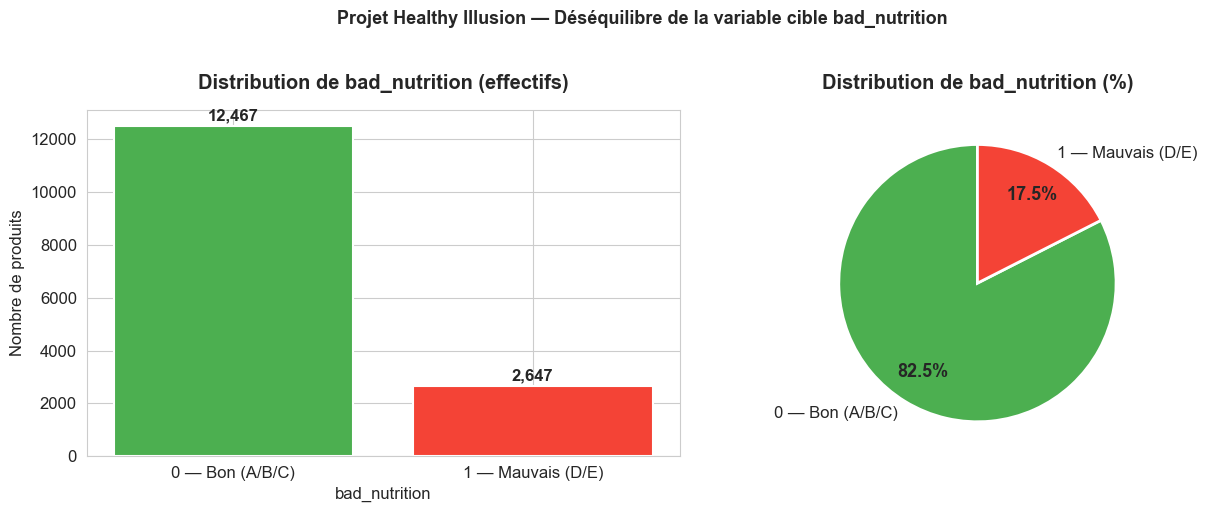

Graphique sauvegardé → data/distribution_bad_nutrition.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

couleurs = ['#4CAF50', '#F44336']
labels   = ['0 — Bon (A/B/C)', '1 — Mauvais (D/E)']
valeurs  = [vc.get(0, 0), vc.get(1, 0)]

# Graphique barres
bars = axes[0].bar(labels, valeurs, color=couleurs, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution de bad_nutrition (effectifs)', fontweight='bold', pad=15)
axes[0].set_ylabel('Nombre de produits')
axes[0].set_xlabel('bad_nutrition')
for bar, val in zip(bars, valeurs):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(valeurs) * 0.01,
        f'{val:,}',
        ha='center', va='bottom', fontweight='bold'
    )

# Graphique camembert
wedges, texts, autotexts = axes[1].pie(
    valeurs,
    labels=labels,
    colors=couleurs,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)
axes[1].set_title('Distribution de bad_nutrition (%)', fontweight='bold', pad=15)

plt.suptitle(
    'Projet Healthy Illusion — Déséquilibre de la variable cible bad_nutrition',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('data/distribution_bad_nutrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé → data/distribution_bad_nutrition.png')

## 8. Graphique — Distribution de `image_saine` et `healthy_illusion`

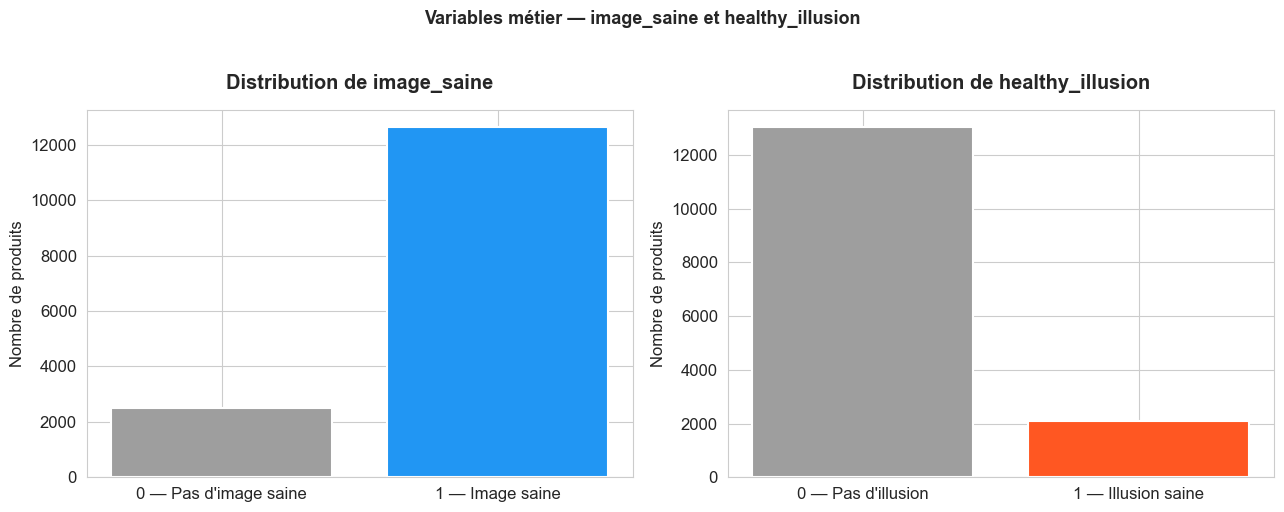

Graphique sauvegardé → data/distribution_metier.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# image_saine
vc_is = df['image_saine'].value_counts().sort_index()
axes[0].bar(
    ['0 — Pas d\'image saine', '1 — Image saine'],
    [vc_is.get(0, 0), vc_is.get(1, 0)],
    color=['#9E9E9E', '#2196F3'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribution de image_saine', fontweight='bold', pad=15)
axes[0].set_ylabel('Nombre de produits')

# healthy_illusion
vc_hi = df['healthy_illusion'].value_counts().sort_index()
axes[1].bar(
    ['0 — Pas d\'illusion', '1 — Illusion saine'],
    [vc_hi.get(0, 0), vc_hi.get(1, 0)],
    color=['#9E9E9E', '#FF5722'],
    edgecolor='white', linewidth=1.5
)
axes[1].set_title('Distribution de healthy_illusion', fontweight='bold', pad=15)
axes[1].set_ylabel('Nombre de produits')

plt.suptitle('Variables métier — image_saine et healthy_illusion',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/distribution_metier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé → data/distribution_metier.png')

## 9. Distribution du Nutri-Score

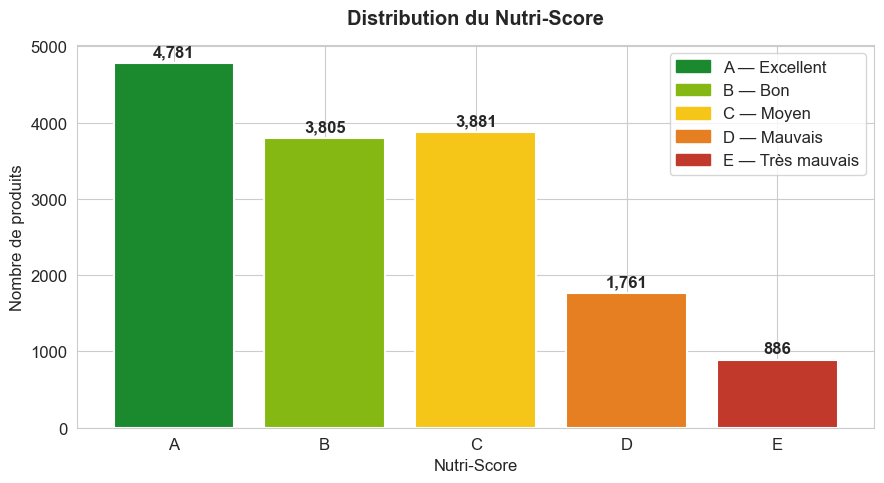

 Graphique sauvegardé → data/distribution_nutriscore.png


In [11]:
# Tracer la distribution du Nutri-Score si la colonne existe dans le CSV
couleurs_ns = {
    'a': '#1B8A2E',
    'b': '#85B812',
    'c': '#F5C518',
    'd': '#E67E22',
    'e': '#C0392B'
}

if 'nutriscore_grade' in df.columns:
    vc_ns = df['nutriscore_grade'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(
        [s.upper() for s in vc_ns.index],
        vc_ns.values,
        color=[couleurs_ns.get(s, '#999') for s in vc_ns.index],
        edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, vc_ns.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vc_ns.values) * 0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold'
        )

    ax.set_title('Distribution du Nutri-Score', fontweight='bold', pad=15)
    ax.set_xlabel('Nutri-Score')
    ax.set_ylabel('Nombre de produits')

    legende = [
        mpatches.Patch(color='#1B8A2E', label='A — Excellent'),
        mpatches.Patch(color='#85B812', label='B — Bon'),
        mpatches.Patch(color='#F5C518', label='C — Moyen'),
        mpatches.Patch(color='#E67E22', label='D — Mauvais'),
        mpatches.Patch(color='#C0392B', label='E — Très mauvais'),
    ]
    ax.legend(handles=legende, loc='upper right')

    plt.tight_layout()
    plt.savefig('data/distribution_nutriscore.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Graphique sauvegardé → data/distribution_nutriscore.png')
else:
    print(" La colonne 'nutriscore_grade' est absente du CSV — section Nutri-Score ignorée.")

**Attention — fuite de données (data leakage)**

La colonne `nutriscore_grade` est utilisée pour construire la cible `bad_nutrition`.
Elle ne doit JAMAIS être fournie comme feature au modèle lors de l'entraînement.
Ce notebook vérifie la présence de `nutriscore_grade` avant toute visualisation et
n'inclura pas cette colonne dans la liste finale des `FEATURES_ML`.

## 10. Vérification des features ML

In [12]:
# Features qui seront utilisées en Phase 2
FEATURES_ML = [
    'sugars_100g',
    'fat_100g',
    'saturated_fat_100g',
    'salt_100g',
    'fiber_100g',
    'proteins_100g',
    'energy_kcal_100g',
    'additives_count',
    'has_labels',
    'main_category',
    'country',
]

print('Vérification des features ML :')
print('================================')
for feat in FEATURES_ML:
    present = feat in df.columns
    dtype   = df[feat].dtype if present else 'ABSENTE'
    status = "OK" if present else "ABSENTE"
    print(f'   {status:<8} {feat:<25} type={dtype}')

print(f'\nNombre de features : {len(FEATURES_ML)}')
print(f'Contrainte prof (>= 8) : {" OK" if len(FEATURES_ML) >= 8 else " NON"}')

Vérification des features ML :
   OK       sugars_100g               type=float64
   OK       fat_100g                  type=float64
   OK       saturated_fat_100g        type=float64
   OK       salt_100g                 type=float64
   OK       fiber_100g                type=float64
   OK       proteins_100g             type=float64
   OK       energy_kcal_100g          type=float64
   OK       additives_count           type=int64
   OK       has_labels                type=int64
   OK       main_category             type=str
   OK       country                   type=str

Nombre de features : 11
Contrainte prof (>= 8) :  OK


In [14]:
# Sécurité : exclure `nutriscore_grade` des features si elle est présente
if 'nutriscore_grade' in FEATURES_ML:
    FEATURES_ML = [f for f in FEATURES_ML if f != 'nutriscore_grade']
    print(" 'nutriscore_grade' trouvée dans FEATURES_ML — exclue automatiquement.")
else:
    print("FEATURES_ML prêts — 'nutriscore_grade' non incluse.")

FEATURES_ML prêts — 'nutriscore_grade' non incluse.


## 11. Vérification finale 

In [13]:
ratio = df['bad_nutrition'].value_counts(normalize=True).min() * 100

print('=' * 55)
print('VÉRIFICATION CONTRAINTES PROF')
print('=' * 55)

checks = [
    ('Taille >= 10 000 lignes',
     len(df) >= 10000,
     f'{len(df):,} lignes'),

    ('Features >= 8',
     len(FEATURES_ML) >= 8,
     f'{len(FEATURES_ML)} features'),

    ('Classe minoritaire 5%-25%',
     5 <= ratio <= 25,
     f'{ratio:.1f}%'),

    ('Variables numériques présentes',
     'sugars_100g' in df.columns,
     'sugars, fat, salt, fiber, protein, energy, additives'),

    ('Variables catégorielles présentes',
     'main_category' in df.columns,
     'main_category, country, has_labels, image_saine'),

    ('Variable cible bad_nutrition présente',
     'bad_nutrition' in df.columns,
     'bad_nutrition (0 ou 1)'),

    ('Classification supervisée binaire',
     df['bad_nutrition'].nunique() == 2,
     f'valeurs uniques : {sorted(df["bad_nutrition"].unique())}'),
]

for nom, ok, detail in checks:
    print(f'    {nom}')
    print(f'        → {detail}')

tout_ok = all(ok for _, ok, _ in checks)
print('\n' + '=' * 55)
if tout_ok:
    print(' DATASET CONFORME — prêt pour la Phase 2 !')
else:
    print(' DATASET PAS ENCORE CONFORME — voir les points en rouge.')
print('=' * 55)

VÉRIFICATION CONTRAINTES PROF
    Taille >= 10 000 lignes
        → 15,114 lignes
    Features >= 8
        → 11 features
    Classe minoritaire 5%-25%
        → 17.5%
    Variables numériques présentes
        → sugars, fat, salt, fiber, protein, energy, additives
    Variables catégorielles présentes
        → main_category, country, has_labels, image_saine
    Variable cible bad_nutrition présente
        → bad_nutrition (0 ou 1)
    Classification supervisée binaire
        → valeurs uniques : [np.int64(0), np.int64(1)]

 DATASET CONFORME — prêt pour la Phase 2 !


## 12. Conclusion

In [14]:
print('CONCLUSION DU NOTEBOOK 01_DISCOVERY')
print('======================================')
print()
print(f'Dataset : {len(df):,} produits alimentaires')
print(f'Source  : Open Food Facts (API publique gratuite)')
print(f'Cible   : bad_nutrition (Nutri-Score D/E = 1)')
print()
print(f'Déséquilibre naturel constaté :')
print(f'  bad_nutrition = 0 : {df["bad_nutrition"].value_counts().get(0,0):,} produits')
print(f'  bad_nutrition = 1 : {df["bad_nutrition"].value_counts().get(1,0):,} produits')
print()
print(f'Analyse métier :')
print(f'  image_saine = 1      : {df["image_saine"].sum():,} produits présentés comme sains')
print(f'  healthy_illusion = 1 : {df["healthy_illusion"].sum():,} produits à illusion saine')
print()
print('Le dataset est exploitable pour la Phase 2.')
print('Les métriques à utiliser : Recall, Precision, F1-score, PR-AUC')
print('(Accuracy refusée comme métrique principale — données déséquilibrées)')

CONCLUSION DU NOTEBOOK 01_DISCOVERY

Dataset : 15,114 produits alimentaires
Source  : Open Food Facts (API publique gratuite)
Cible   : bad_nutrition (Nutri-Score D/E = 1)

Déséquilibre naturel constaté :
  bad_nutrition = 0 : 12,467 produits
  bad_nutrition = 1 : 2,647 produits

Analyse métier :
  image_saine = 1      : 12,624 produits présentés comme sains
  healthy_illusion = 1 : 2,089 produits à illusion saine

Le dataset est exploitable pour la Phase 2.
Les métriques à utiliser : Recall, Precision, F1-score, PR-AUC
(Accuracy refusée comme métrique principale — données déséquilibrées)
